<a href="https://colab.research.google.com/github/Kenduiwo/kenduiwo/blob/main/student%20performance%20prediction%20using%20ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
pd.options.display.max_columns = None

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Students.csv')
df.head()

,Unnamed: 0,Adm_Year,Gender,Age,HSC_Pass_Year,Program,Merit_Scholarship,Uni_Transport,Learn_Mode,Smartphone,PC,Eng_Proficiency,Probation,Suspension,Do you attend in teacher consultancy for any kind of academical problems?,Relationship,CoCurricular,Living_Arrangement,Health_Issues,Physical_Disabilities,Target,Curr_Sem1,Study_Hours1,Study_Sessions1,SM_Hours1,Avg_Attendance1,Skills1,Skill_Dev_Hours1,Interest_Area1,Prev_SGPA1,Curr_CGPA1,Completed_Credits1,Diploma,Family_Income1
0,7,2021.0,Female,22.0,2019.0,BCSE,Yes,No,Offline,Yes,Yes,Basic,Yes,No,Yes,Single,No,Bachelor,No,No,Good,4.0,2.0,2.0,2.0,100.0,Web development skill(Frontend),1.0,Networking,3.80,3.64,35.0,False,32500.0
1,11,2021.0,Male,22.0,2019.0,BCSE,No,No,Offline,Yes,Yes,Basic,No,No,No,Single,No,Bachelor,Yes,No,Good,4.0,3.5,2.0,2.0,90.0,Programming,1.0,Data Science,3.40,3.53,35.0,False,20000.0
2,15,2021.0,Male,20.0,2020.0,BCSE,Yes,Yes,Offline,Yes,Yes,Basic,No,No,Yes,Single,Yes,Family,No,No,Good,4.0,2.0,1.0,1.0,95.0,Programming,3.0,Machine Learning / Deep Learning,3.93,3.89,35.0,False,30000.0
3,18,2021.0,Male,21.0,2020.0,BCSE,Yes,No,Online,Yes,Yes,Advance,No,No,Yes,In a relationship,No,Family,No,No,Average,4.0,1.0,2.0,3.0,95.0,Programming,1.0,Artificial Intelligence,3.10,3.50,35.0,False,25000.0
4,20,2021.0,Female,21.0,2019.0,BCSE,Yes,No,Offline,Yes,Yes,Intermediate,No,No,Yes,Single,Yes,Bachelor,No,No,Good,4.0,3.0,2.0,2.0,96.0,Web development skill(Frontend),1.0,Web Development,3.81,3.65,34.0,False,30000.0


In [ ]:
df.columns

Index(['Unnamed: 0', 'Adm_Year', 'Gender', 'Age', 'HSC_Pass_Year', 'Program',
       'Merit_Scholarship', 'Uni_Transport', 'Learn_Mode', 'Smartphone', 'PC',
       'Eng_Proficiency', 'Probation', 'Suspension',
       'Do you attend in teacher consultancy for any kind of academical problems? ',
       'Relationship', 'CoCurricular', 'Living_Arrangement', 'Health_Issues',
       'Physical_Disabilities', 'Target', 'Curr_Sem1', 'Study_Hours1',
       'Study_Sessions1', 'SM_Hours1', 'Avg_Attendance1', 'Skills1',
       'Skill_Dev_Hours1', 'Interest_Area1', 'Prev_SGPA1', 'Curr_CGPA1',
       'Completed_Credits1', 'Diploma', 'Family_Income1'],
      dtype='object')

In [ ]:
df.shape

(1009, 34)

In [ ]:
df.isnull().sum()

Unnamed: 0                                                                    0
Adm_Year                                                                      0
Gender                                                                        0
Age                                                                           0
HSC_Pass_Year                                                                 0
Program                                                                       0
Merit_Scholarship                                                             0
Uni_Transport                                                                 0
Learn_Mode                                                                    0
Smartphone                                                                    0
PC                                                                            0
Eng_Proficiency                                                               0
Probation                               

In [ ]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [ ]:
duplicate = df.duplicated()
print(duplicate.sum())

0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 33 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Adm_Year                                                                    1009 non-null   float64
 1   Gender                                                                      1009 non-null   object 
 2   Age                                                                         1009 non-null   float64
 3   HSC_Pass_Year                                                               1009 non-null   float64
 4   Program                                                                     1009 non-null   object 
 5   Merit_Scholarship                                                           1009 non-null   object 
 6   Uni_Transport                                   

In [ ]:
df.head()

,Adm_Year,Gender,Age,HSC_Pass_Year,Program,Merit_Scholarship,Uni_Transport,Learn_Mode,Smartphone,PC,Eng_Proficiency,Probation,Suspension,Do you attend in teacher consultancy for any kind of academical problems?,Relationship,CoCurricular,Living_Arrangement,Health_Issues,Physical_Disabilities,Target,Curr_Sem1,Study_Hours1,Study_Sessions1,SM_Hours1,Avg_Attendance1,Skills1,Skill_Dev_Hours1,Interest_Area1,Prev_SGPA1,Curr_CGPA1,Completed_Credits1,Diploma,Family_Income1
0,2021.0,Female,22.0,2019.0,BCSE,Yes,No,Offline,Yes,Yes,Basic,Yes,No,Yes,Single,No,Bachelor,No,No,Good,4.0,2.0,2.0,2.0,100.0,Web development skill(Frontend),1.0,Networking,3.80,3.64,35.0,False,32500.0
1,2021.0,Male,22.0,2019.0,BCSE,No,No,Offline,Yes,Yes,Basic,No,No,No,Single,No,Bachelor,Yes,No,Good,4.0,3.5,2.0,2.0,90.0,Programming,1.0,Data Science,3.40,3.53,35.0,False,20000.0
2,2021.0,Male,20.0,2020.0,BCSE,Yes,Yes,Offline,Yes,Yes,Basic,No,No,Yes,Single,Yes,Family,No,No,Good,4.0,2.0,1.0,1.0,95.0,Programming,3.0,Machine Learning / Deep Learning,3.93,3.89,35.0,False,30000.0
3,2021.0,Male,21.0,2020.0,BCSE,Yes,No,Online,Yes,Yes,Advance,No,No,Yes,In a relationship,No,Family,No,No,Average,4.0,1.0,2.0,3.0,95.0,Programming,1.0,Artificial Intelligence,3.10,3.50,35.0,False,25000.0
4,2021.0,Female,21.0,2019.0,BCSE,Yes,No,Offline,Yes,Yes,Intermediate,No,No,Yes,Single,Yes,Bachelor,No,No,Good,4.0,3.0,2.0,2.0,96.0,Web development skill(Frontend),1.0,Web Development,3.81,3.65,34.0,False,30000.0


In [ ]:
df['Skills1']=df['Skills1'].fillna(df['Skills1'].mode()[0])
df['Interest_Area1']=df['Interest_Area1'].fillna(df['Interest_Area1'].mode()[0])

In [ ]:
df.isnull().sum()

Adm_Year                                                                      0
Gender                                                                        0
Age                                                                           0
HSC_Pass_Year                                                                 0
Program                                                                       0
Merit_Scholarship                                                             0
Uni_Transport                                                                 0
Learn_Mode                                                                    0
Smartphone                                                                    0
PC                                                                            0
Eng_Proficiency                                                               0
Probation                                                                     0
Suspension                              

In [ ]:
df['Target'].value_counts()

Target
Poor         503
Average      272
Good         178
Excellent     56
Name: count, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 33 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Adm_Year                                                                    1009 non-null   float64
 1   Gender                                                                      1009 non-null   object 
 2   Age                                                                         1009 non-null   float64
 3   HSC_Pass_Year                                                               1009 non-null   float64
 4   Program                                                                     1009 non-null   object 
 5   Merit_Scholarship                                                           1009 non-null   object 
 6   Uni_Transport                                   

In [ ]:
df.isnull().sum()

Adm_Year                                                                      0
Gender                                                                        0
Age                                                                           0
HSC_Pass_Year                                                                 0
Program                                                                       0
Merit_Scholarship                                                             0
Uni_Transport                                                                 0
Learn_Mode                                                                    0
Smartphone                                                                    0
PC                                                                            0
Eng_Proficiency                                                               0
Probation                                                                     0
Suspension                              

In [ ]:
duplicates=df.duplicated()
print(duplicates.sum())

0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 33 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Adm_Year                                                                    1009 non-null   float64
 1   Gender                                                                      1009 non-null   object 
 2   Age                                                                         1009 non-null   float64
 3   HSC_Pass_Year                                                               1009 non-null   float64
 4   Program                                                                     1009 non-null   object 
 5   Merit_Scholarship                                                           1009 non-null   object 
 6   Uni_Transport                                   

#Data preprocessing

In [ ]:
df['Skills1']=df['Skills1'].fillna(df['Skills1'].mode()[0])
df['Interest_Area1']=df['Interest_Area1'].fillna(df['Interest_Area1'].mode()[0])

In [ ]:
df.isnull().sum()

Adm_Year                                                                      0
Gender                                                                        0
Age                                                                           0
HSC_Pass_Year                                                                 0
Program                                                                       0
Merit_Scholarship                                                             0
Uni_Transport                                                                 0
Learn_Mode                                                                    0
Smartphone                                                                    0
PC                                                                            0
Eng_Proficiency                                                               0
Probation                                                                     0
Suspension                              

#visualization

In [ ]:
cat_cols = df.select_dtypes(include=['object','category','bool']).columns
cat_cols

Index(['Gender', 'Program', 'Merit_Scholarship', 'Uni_Transport', 'Learn_Mode',
       'Smartphone', 'PC', 'Eng_Proficiency', 'Probation', 'Suspension',
       'Do you attend in teacher consultancy for any kind of academical problems? ',
       'Relationship', 'CoCurricular', 'Living_Arrangement', 'Health_Issues',
       'Physical_Disabilities', 'Target', 'Skills1', 'Interest_Area1',
       'Diploma'],
      dtype='object')

In [ ]:
num_cols =df.select_dtypes(include=['int64','float64','number']).columns
num_cols

Index(['Adm_Year', 'Age', 'HSC_Pass_Year', 'Curr_Sem1', 'Study_Hours1',
       'Study_Sessions1', 'SM_Hours1', 'Avg_Attendance1', 'Skill_Dev_Hours1',
       'Prev_SGPA1', 'Curr_CGPA1', 'Completed_Credits1', 'Family_Income1'],
      dtype='object')

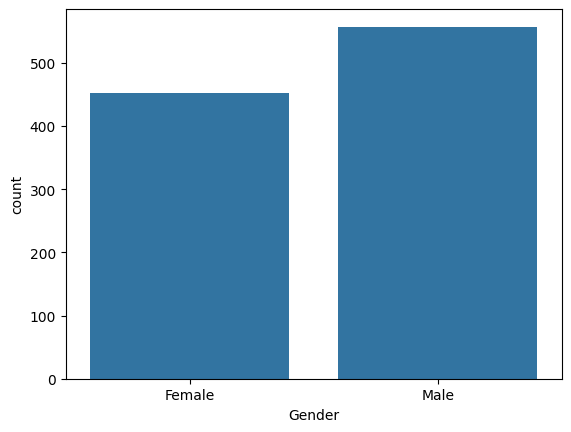

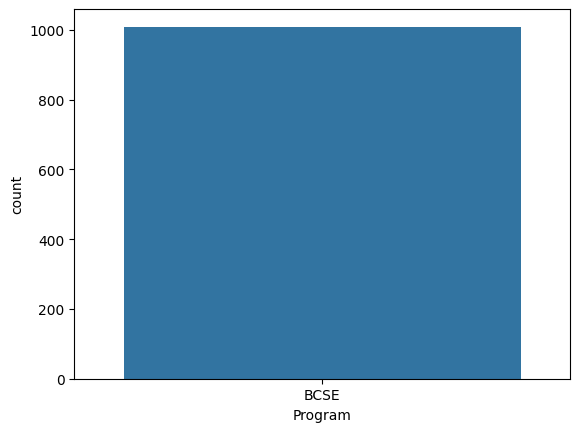

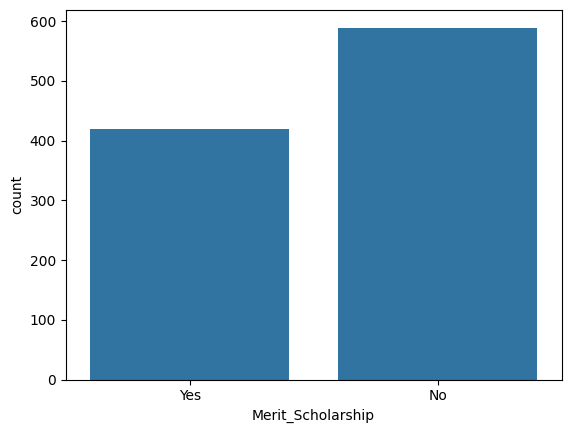

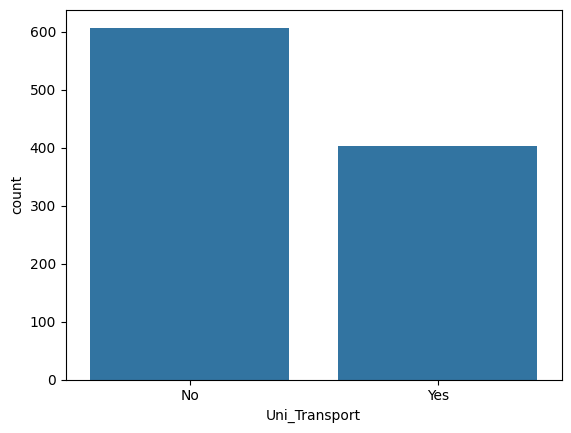

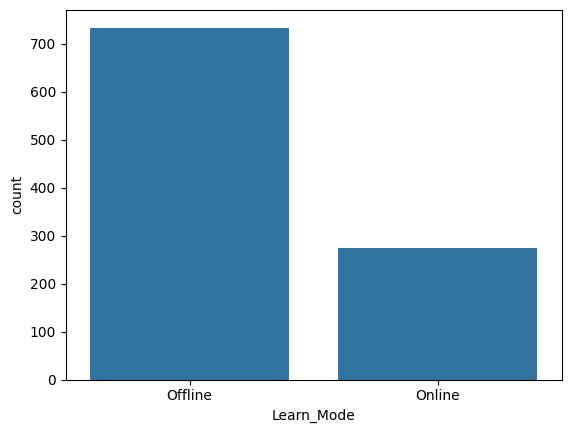

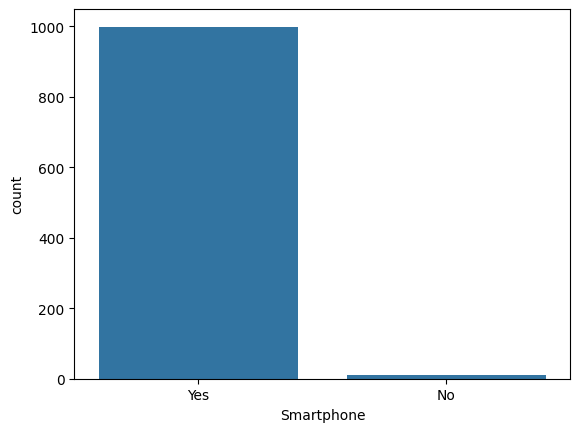

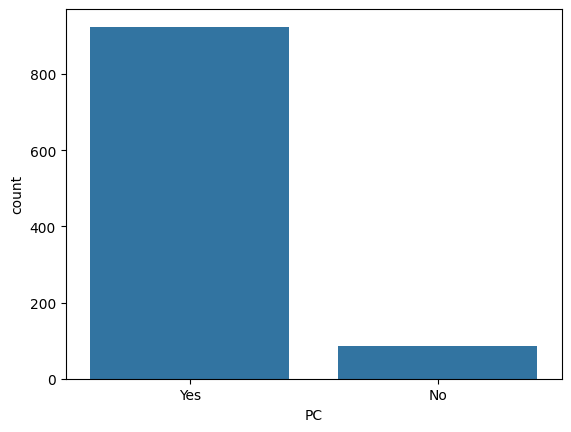

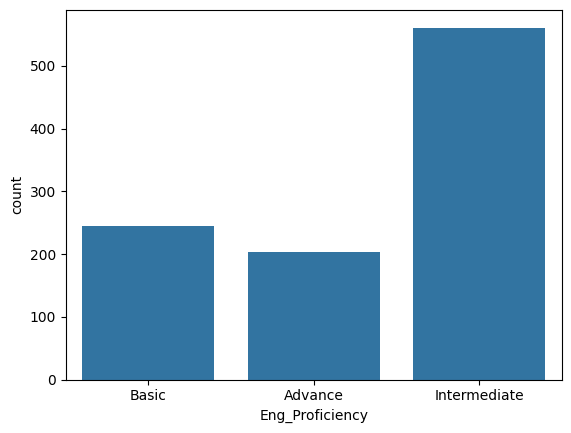

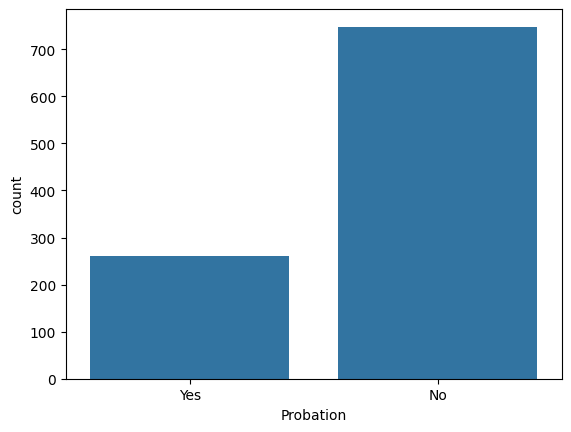

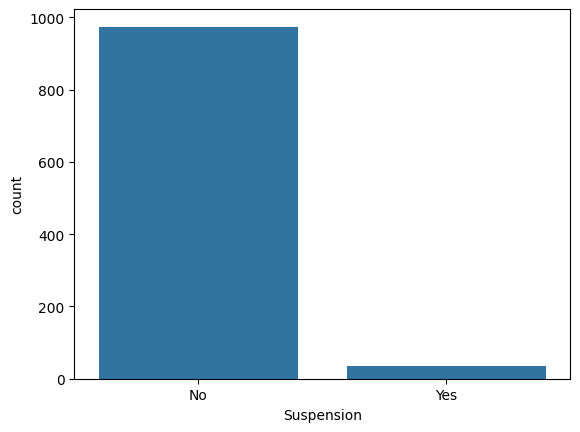

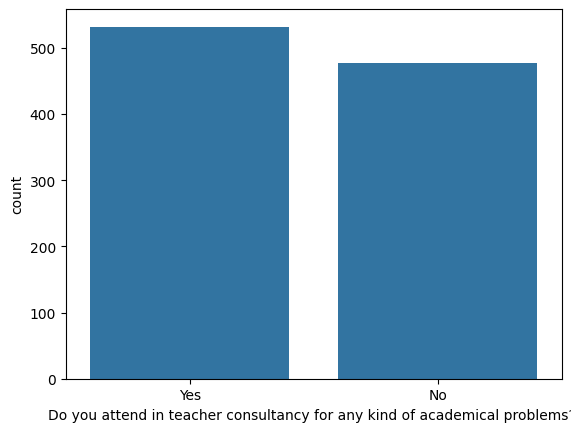

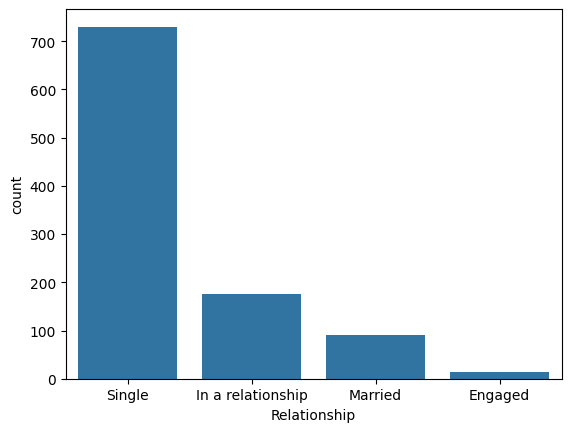

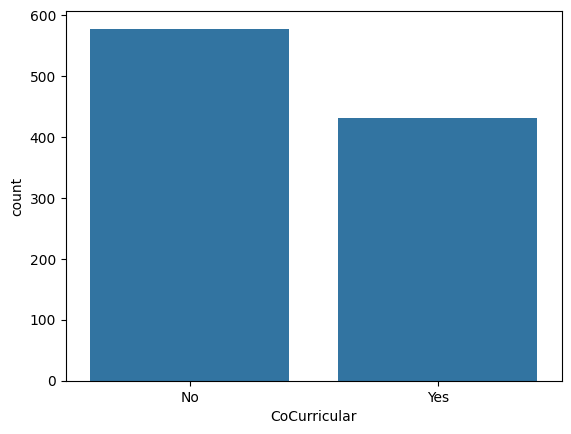

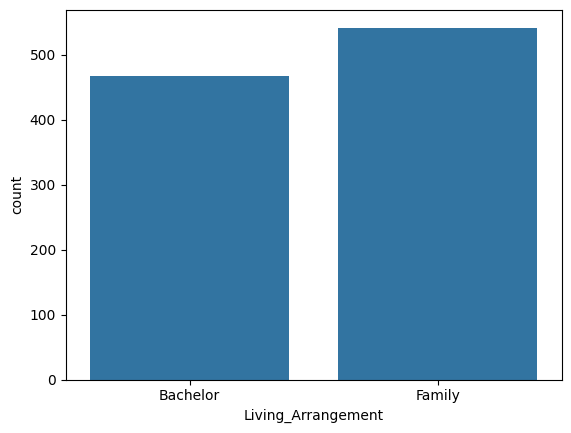

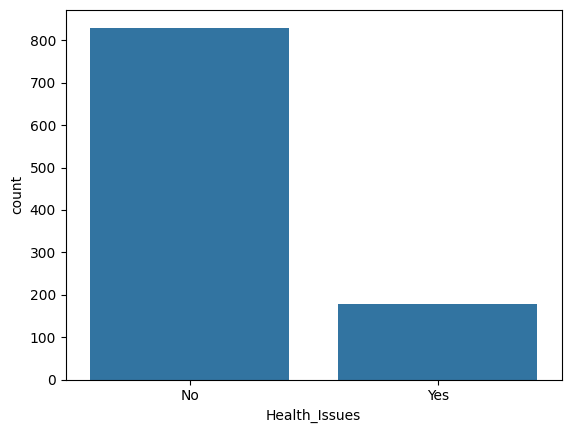

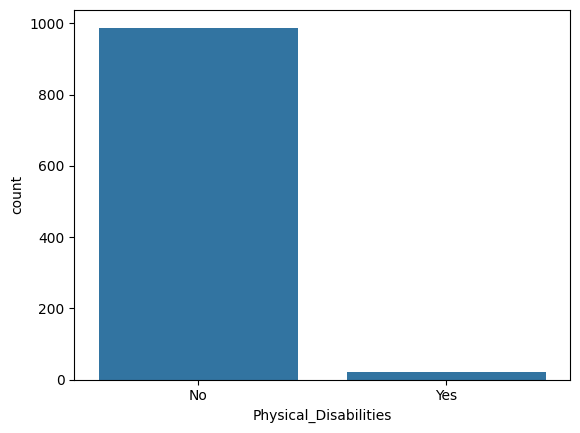

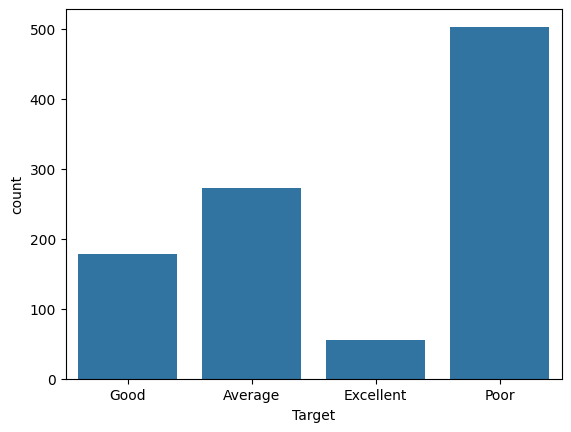

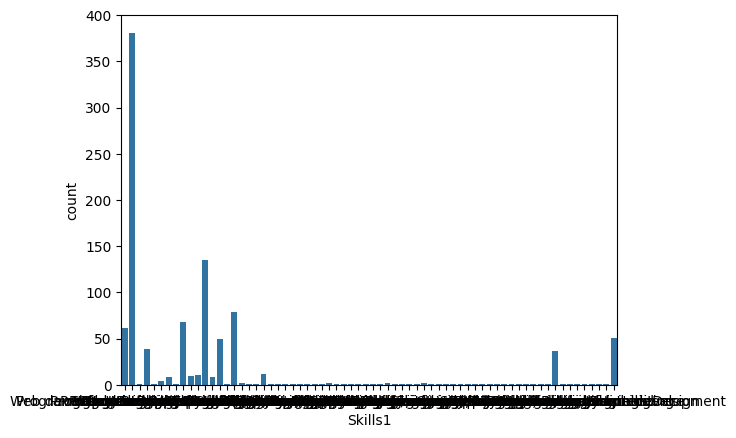

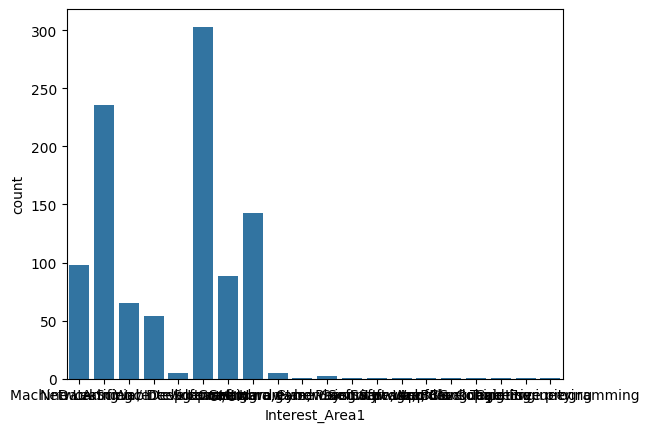

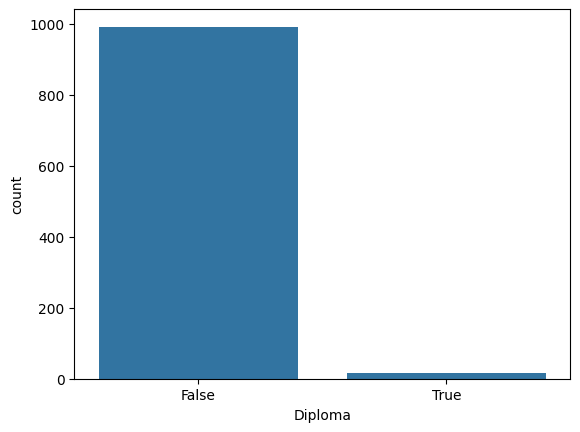

In [ ]:
for i in cat_cols:
  sns.countplot(x=i,data=df)
  plt.show()

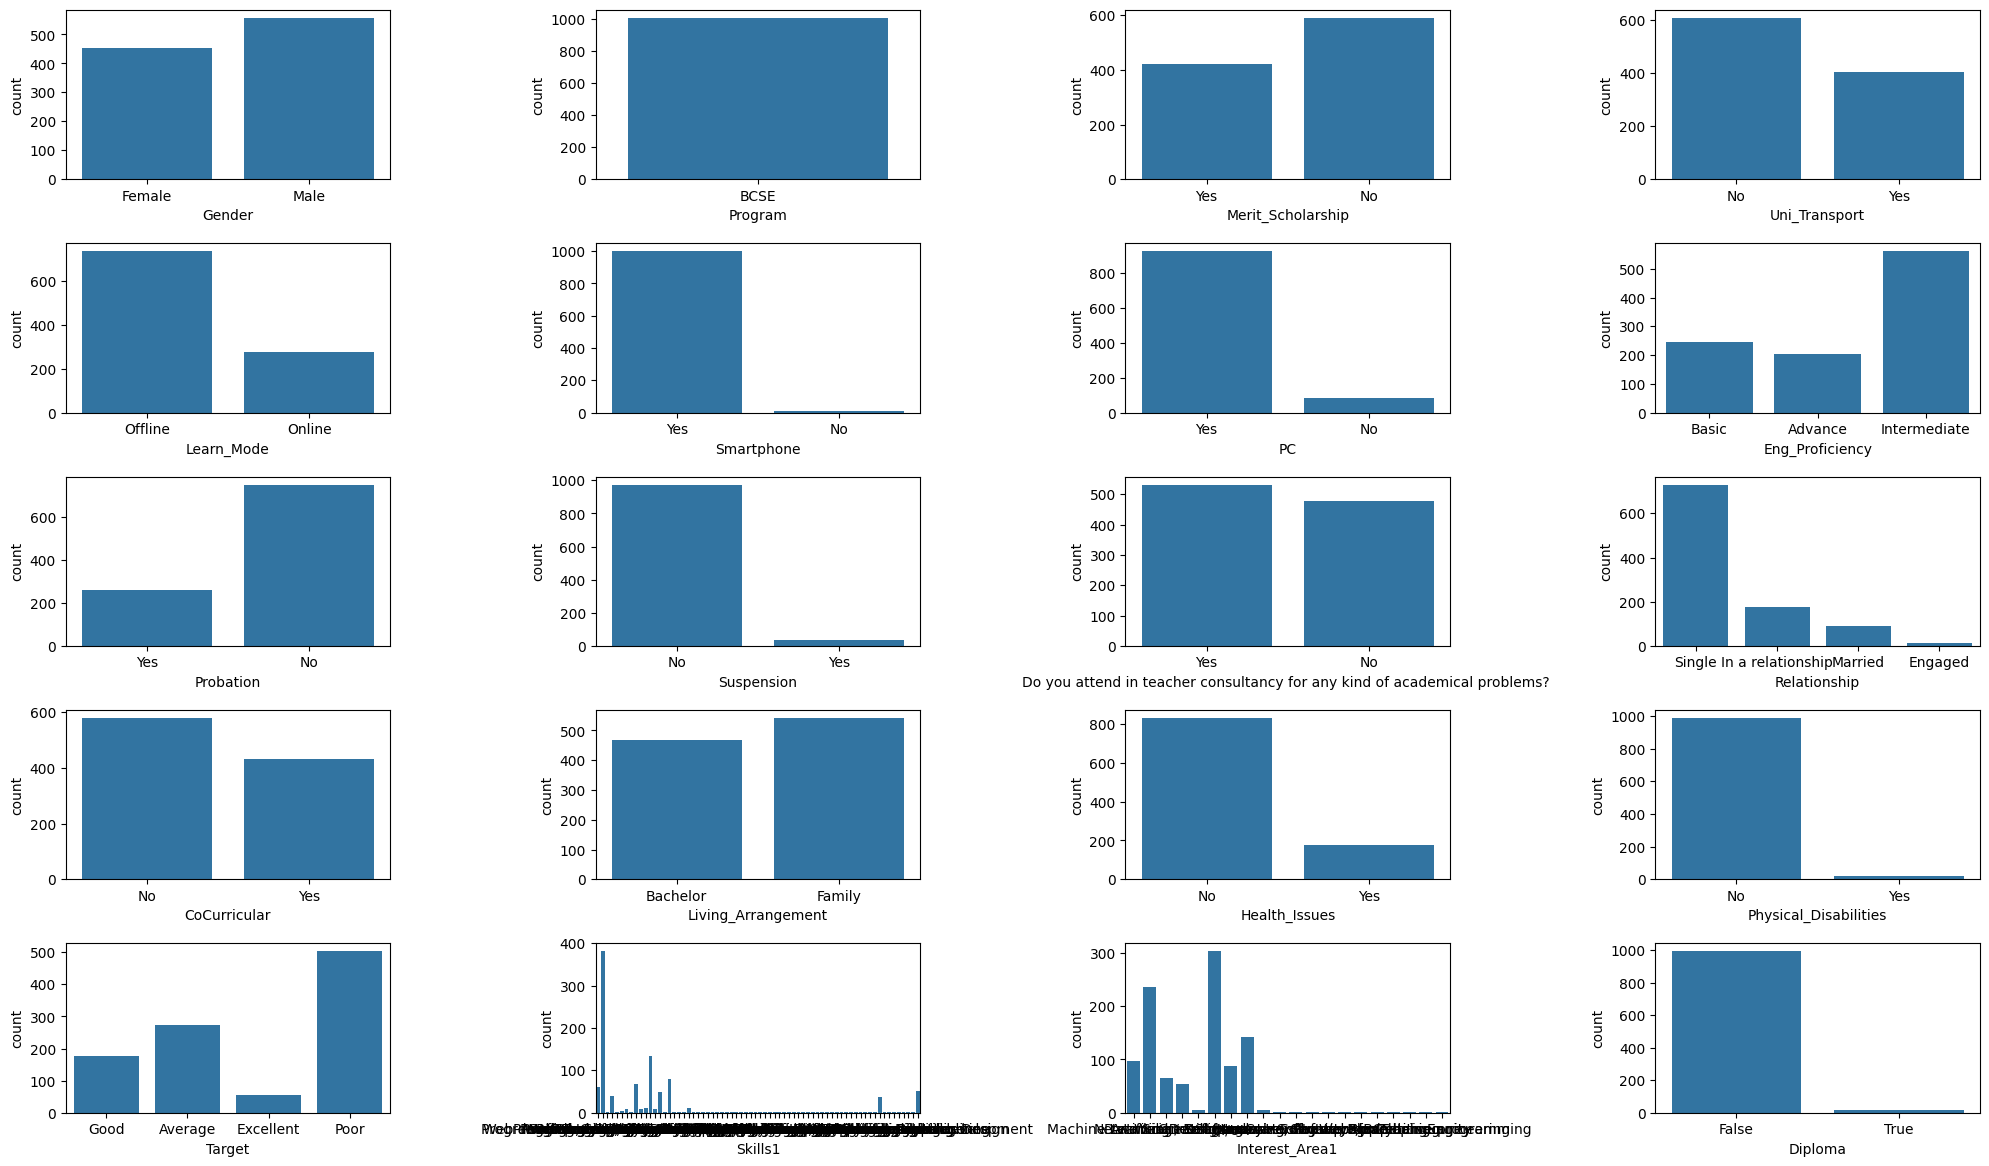

In [ ]:
i=1
plt.figure(figsize=(20,16))
for col in cat_cols:
  plt.subplot(7,4,i)
  sns.countplot(x=col,data=df)
  i+=1
  plt.tight_layout()
plt.show()

# Numerical datasets

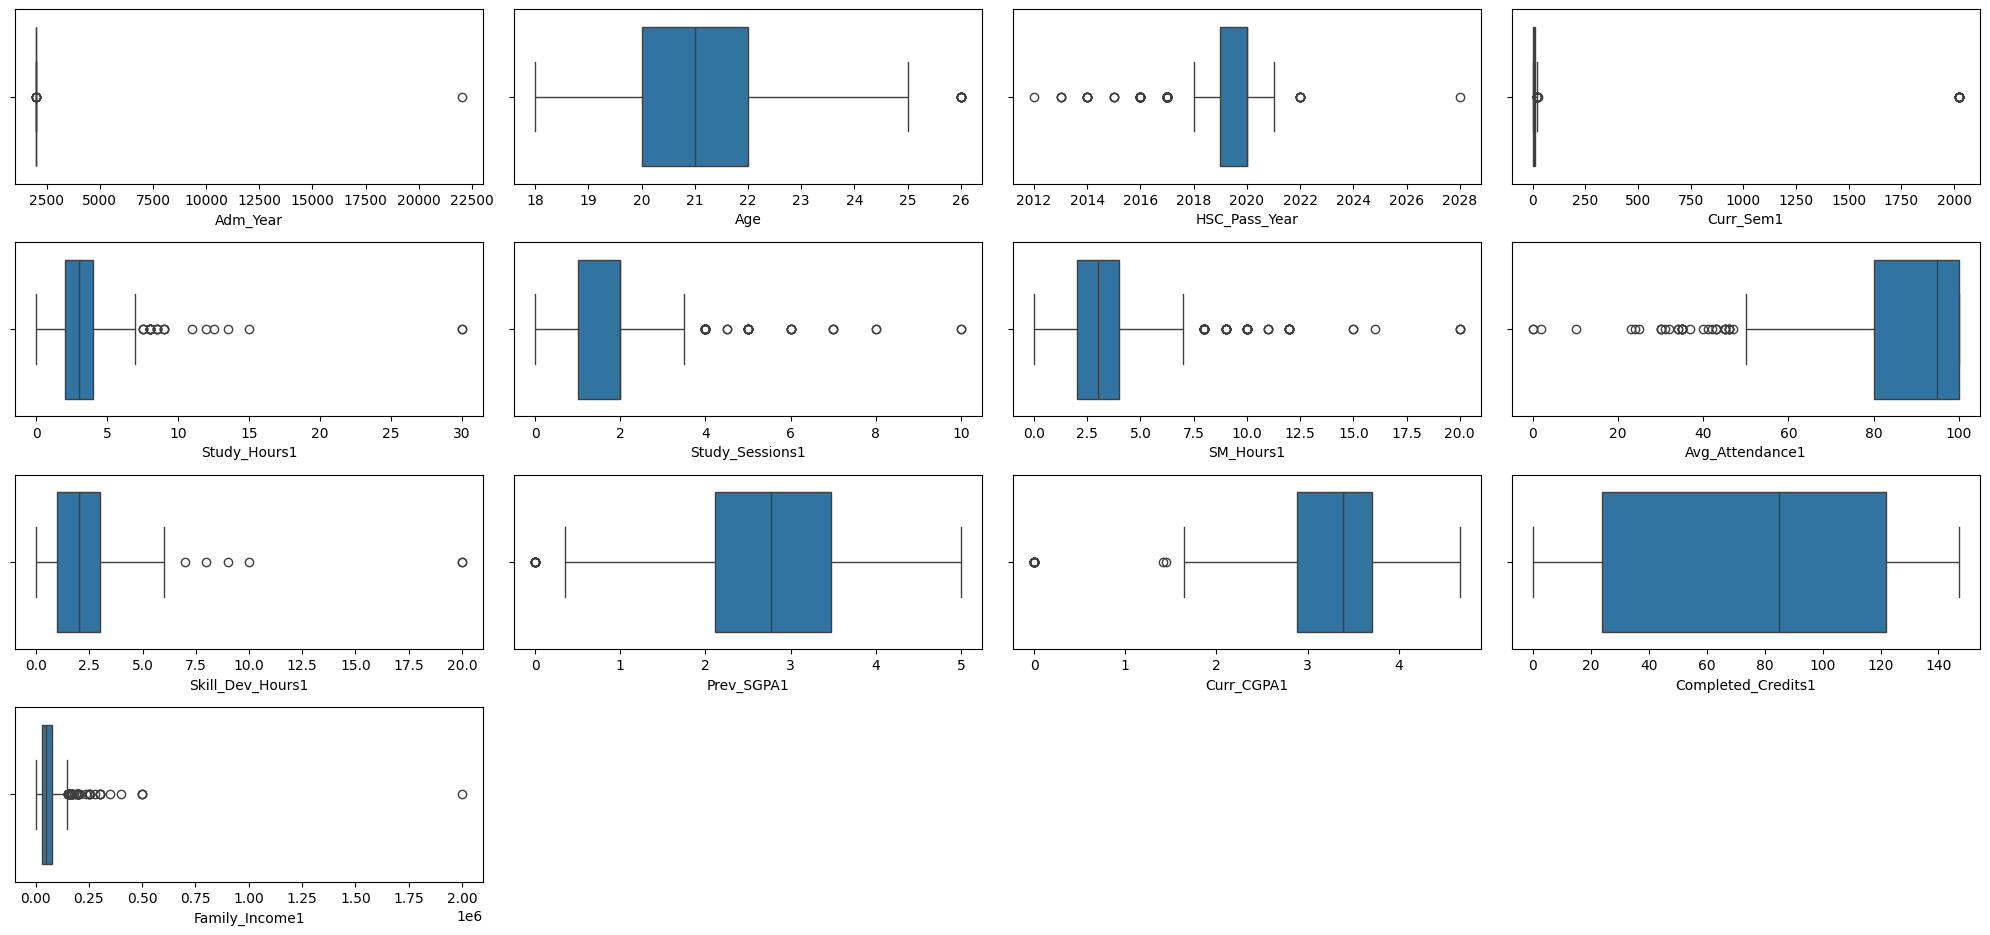

In [ ]:
i=1
plt.figure(figsize=(20,16))
for col in num_cols:
  plt.subplot(7,4,i)
  sns.boxplot(x=col,data=df)
  i+=1
  plt.tight_layout()
plt.show()

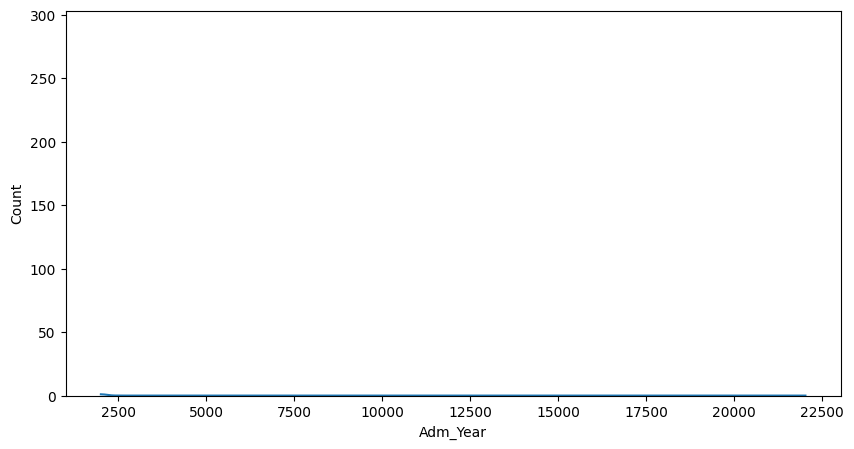

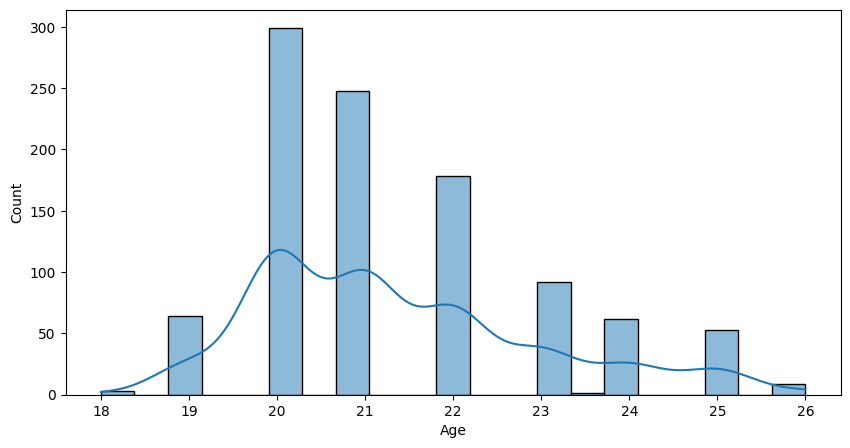

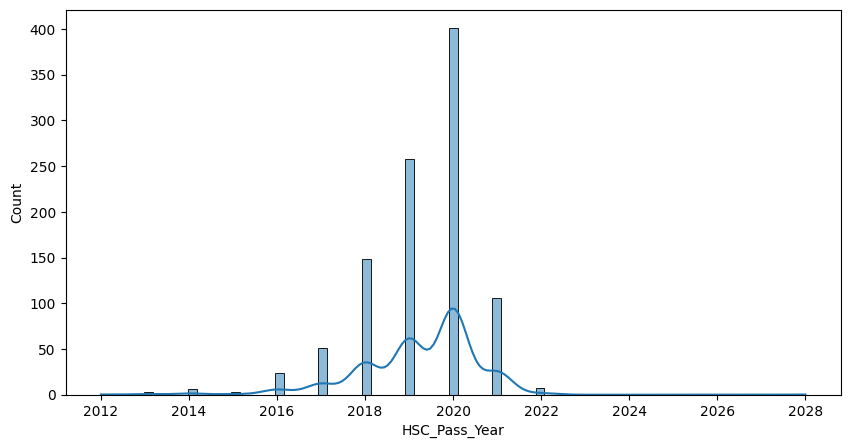

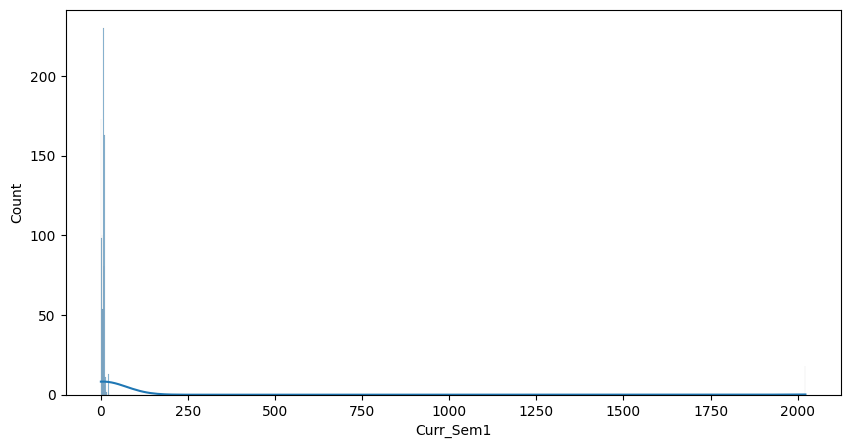

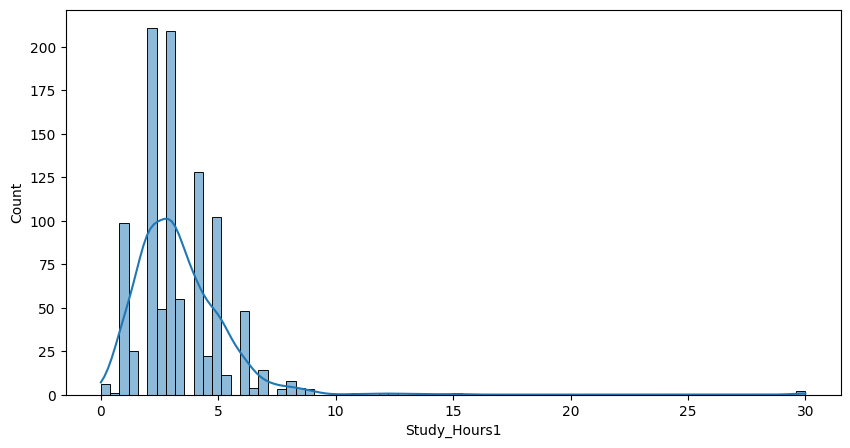

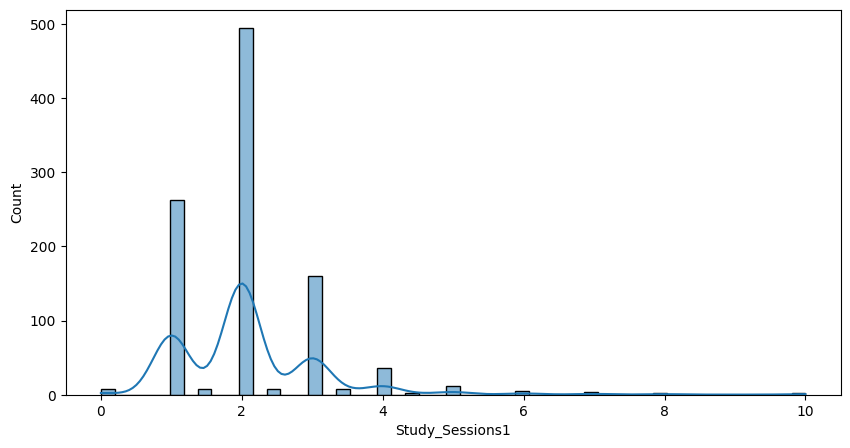

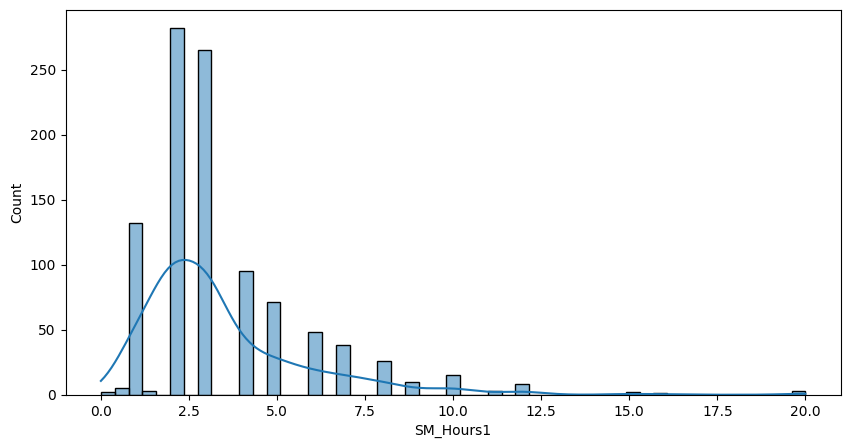

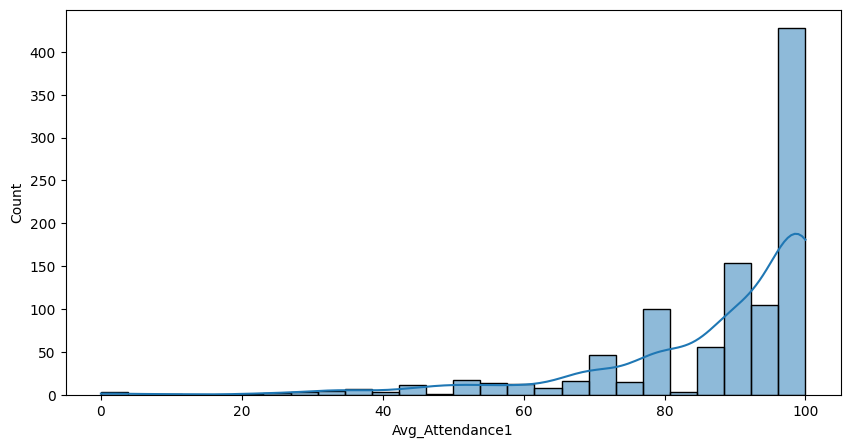

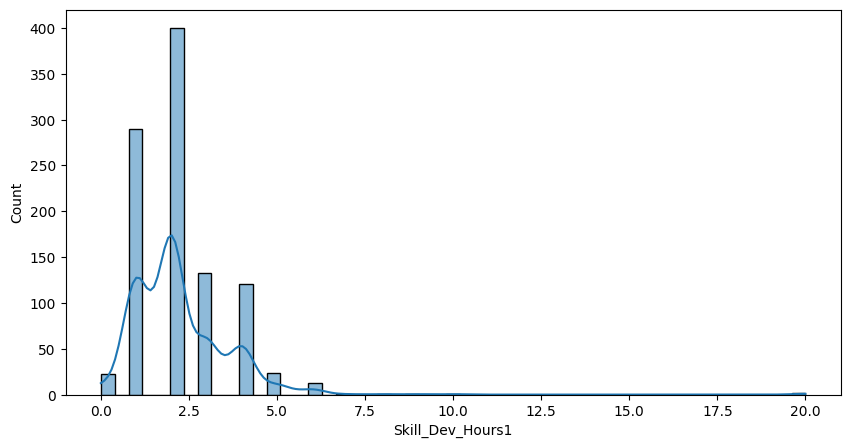

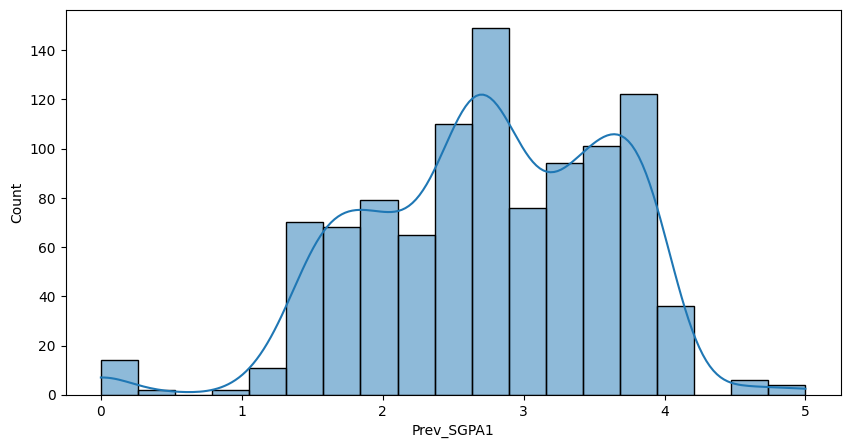

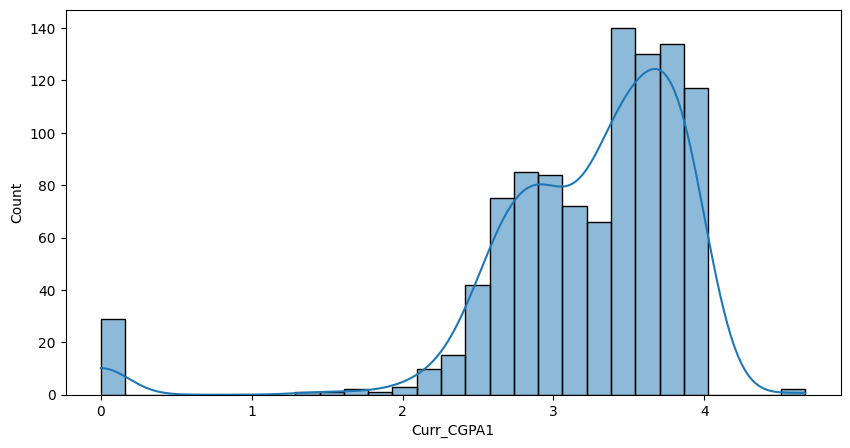

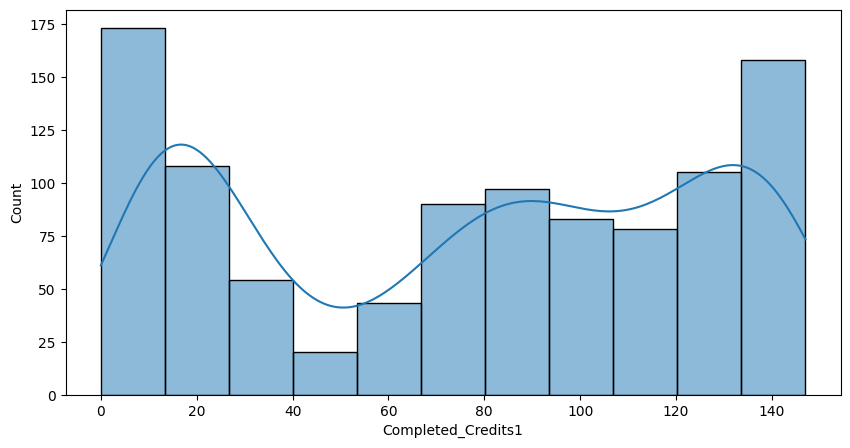

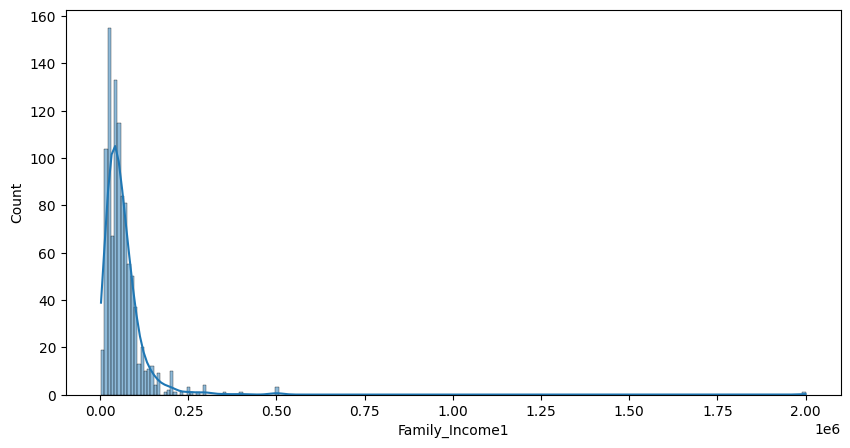

In [ ]:
for i in num_cols:
  plt.figure(figsize=(10,5))
  sns.histplot(df[i],kde=True)
  plt.show()

#Encoding

In [ ]:
df.Target.value_counts()

Target
Poor         503
Average      272
Good         178
Excellent     56
Name: count, dtype: int64

In [ ]:
df['Target']=df['Target'].replace({'Excellent':1,'Good':2,'Average':3,'Poor':4})
df['Target']=df['Target'].astype('int64')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 33 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Adm_Year                                                                    1009 non-null   float64
 1   Gender                                                                      1009 non-null   object 
 2   Age                                                                         1009 non-null   float64
 3   HSC_Pass_Year                                                               1009 non-null   float64
 4   Program                                                                     1009 non-null   object 
 5   Merit_Scholarship                                                           1009 non-null   object 
 6   Uni_Transport                                   

#Label Encoding

In [ ]:
cat_cols

Index(['Gender', 'Program', 'Merit_Scholarship', 'Uni_Transport', 'Learn_Mode',
       'Smartphone', 'PC', 'Eng_Proficiency', 'Probation', 'Suspension',
       'Do you attend in teacher consultancy for any kind of academical problems? ',
       'Relationship', 'CoCurricular', 'Living_Arrangement', 'Health_Issues',
       'Physical_Disabilities', 'Target', 'Skills1', 'Interest_Area1',
       'Diploma'],
      dtype='object')

In [ ]:
categorical_columns=['Gender', 'Program', 'Merit_Scholarship', 'Uni_Transport', 'Learn_Mode',
       'Smartphone', 'PC', 'Eng_Proficiency', 'Probation', 'Suspension',
       'Do you attend in teacher consultancy for any kind of academical problems? ',
       'Relationship', 'CoCurricular', 'Living_Arrangement', 'Health_Issues',
       'Physical_Disabilities','Skills1', 'Interest_Area1',
       'Diploma']

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in categorical_columns:
  df[i]=le.fit_transform(df[i])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 33 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Adm_Year                                                                    1009 non-null   float64
 1   Gender                                                                      1009 non-null   int64  
 2   Age                                                                         1009 non-null   float64
 3   HSC_Pass_Year                                                               1009 non-null   float64
 4   Program                                                                     1009 non-null   int64  
 5   Merit_Scholarship                                                           1009 non-null   int64  
 6   Uni_Transport                                   

In [ ]:
df.columns

Index(['Adm_Year', 'Gender', 'Age', 'HSC_Pass_Year', 'Program',
       'Merit_Scholarship', 'Uni_Transport', 'Learn_Mode', 'Smartphone', 'PC',
       'Eng_Proficiency', 'Probation', 'Suspension',
       'Do you attend in teacher consultancy for any kind of academical problems? ',
       'Relationship', 'CoCurricular', 'Living_Arrangement', 'Health_Issues',
       'Physical_Disabilities', 'Target', 'Curr_Sem1', 'Study_Hours1',
       'Study_Sessions1', 'SM_Hours1', 'Avg_Attendance1', 'Skills1',
       'Skill_Dev_Hours1', 'Interest_Area1', 'Prev_SGPA1', 'Curr_CGPA1',
       'Completed_Credits1', 'Diploma', 'Family_Income1'],
      dtype='object')

#stage before modelling

In [ ]:
x=df.drop('Target',axis=1)
y=df['Target']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(f'x_train shape: {x_train.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

x_train shape: (807, 32)
x_test shape: (202, 32)
y_train shape: (807,)
y_test shape: (202,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


#Modelling with LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000,solver='saga')
lr.fit(x_train,y_train)

LogisticRegression(max_iter=1000, solver='saga')

#Prediction

In [ ]:
y_pred=lr.predict(x_test)
y_pred

array([4, 4, 4, 2, 4, 4, 3, 2, 2, 2, 4, 3, 4, 2, 3, 3, 4, 4, 3, 3, 3, 3,
       2, 4, 3, 2, 4, 2, 4, 3, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4, 4, 2, 3, 3,
       2, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 2, 3, 4, 4, 3, 2, 4, 4, 3,
       2, 2, 3, 4, 4, 4, 3, 4, 4, 4, 4, 4, 3, 3, 4, 3, 3, 3, 4, 4, 4, 4,
       2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 3, 3, 4, 2, 4, 4, 3, 3,
       3, 4, 3, 4, 4, 4, 4, 4, 2, 4, 4, 3, 4, 4, 3, 3, 2, 4, 3, 2, 4, 4,
       4, 3, 4, 3, 3, 2, 4, 4, 4, 3, 3, 2, 3, 2, 4, 3, 3, 4, 4, 4, 4, 1,
       4, 4, 4, 3, 4, 4, 4, 2, 4, 2, 4, 4, 4, 2, 4, 2, 2, 4, 2, 4, 2, 2,
       4, 3, 4, 2, 4, 4, 3, 3, 1, 4, 4, 4, 2, 4, 4, 4, 4, 4, 2, 4, 2, 4,
       4, 2, 4, 2])

#Evaluation

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(f'accuracy_score: {accuracy_score(y_test,y_pred)}')
print(f'confusion_matrix: {confusion_matrix(y_test,y_pred)}')
print(f'classification_report: {classification_report(y_test,y_pred)}')

accuracy_score: 0.9900990099009901
confusion_matrix: [[  9   0   0   0]
 [  1  38   0   0]
 [  0   0  49   0]
 [  0   0   1 104]]
classification_report:               precision    recall  f1-score   support

           1       0.90      1.00      0.95         9
           2       1.00      0.97      0.99        39
           3       0.98      1.00      0.99        49
           4       1.00      0.99      1.00       105

    accuracy                           0.99       202
   macro avg       0.97      0.99      0.98       202
weighted avg       0.99      0.99      0.99       202



#Using LGBM classification model to predict

In [ ]:
from lightgbm import LGBMClassifier
lgbm=LGBMClassifier()
lgbm.fit(x_train,y_train)

#Prediction

In [ ]:
y_pred=lgbm.predict(x_test)
y_pred

array([4, 4, 4, 3, 4, 3, 3, 3, 1, 2, 4, 2, 4, 3, 3, 3, 4, 4, 2, 2, 4, 3,
       2, 3, 3, 2, 4, 3, 3, 3, 4, 4, 3, 4, 4, 4, 4, 4, 2, 4, 4, 1, 2, 4,
       1, 4, 4, 4, 3, 4, 4, 4, 3, 4, 4, 4, 4, 2, 1, 4, 4, 2, 2, 4, 4, 3,
       2, 2, 2, 4, 4, 4, 2, 3, 4, 4, 4, 4, 2, 3, 4, 2, 2, 3, 4, 4, 4, 4,
       2, 4, 4, 4, 4, 4, 3, 4, 4, 3, 4, 2, 3, 4, 3, 3, 4, 1, 4, 4, 3, 3,
       3, 4, 3, 4, 4, 4, 4, 4, 1, 4, 3, 3, 3, 4, 3, 3, 2, 4, 2, 2, 3, 4,
       4, 2, 4, 2, 4, 2, 4, 4, 4, 3, 2, 2, 3, 3, 4, 2, 2, 4, 4, 4, 4, 2,
       4, 4, 4, 3, 4, 4, 4, 3, 4, 4, 4, 4, 4, 1, 4, 2, 3, 3, 2, 3, 3, 1,
       4, 1, 2, 2, 3, 3, 2, 3, 3, 4, 4, 4, 3, 4, 4, 4, 4, 3, 1, 4, 2, 4,
       4, 2, 4, 4])

In [ ]:
print(f'accuracy_score: {accuracy_score(y_test,y_pred)}')
print(f'confusion_matrix: {confusion_matrix(y_test,y_pred)}')
print(f'classification_report: {classification_report(y_test,y_pred)}')

accuracy_score: 0.9900990099009901
confusion_matrix: [[  9   0   0   0]
 [  1  38   0   0]
 [  0   0  49   0]
 [  0   0   1 104]]
classification_report:               precision    recall  f1-score   support

           1       0.90      1.00      0.95         9
           2       1.00      0.97      0.99        39
           3       0.98      1.00      0.99        49
           4       1.00      0.99      1.00       105

    accuracy                           0.99       202
   macro avg       0.97      0.99      0.98       202
weighted avg       0.99      0.99      0.99       202

